# Task 3 Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Summary Statistics

In [3]:
df.shape

(8807, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [13]:
df.isnull().sum()  #Analysing missing values

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [7]:
df.isnull().sum().sum() 

np.int64(4307)

In [14]:
df['director'] = df['director'].fillna('Unknown')   # Handling missing values by placing record Unknown
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

In [12]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [15]:
df['release_year'].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [20]:
df.describe(include="object")  # To get summary of non-numeric columns

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807
unique,8807,2,8807,4529,7693,749,1768,18,221,514,8775
top,s1,Movie,Dick Johnson Is Dead,Unknown,Unknown,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2634,825,2818,109,3207,1793,362,4


## Trend Identification

In [22]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

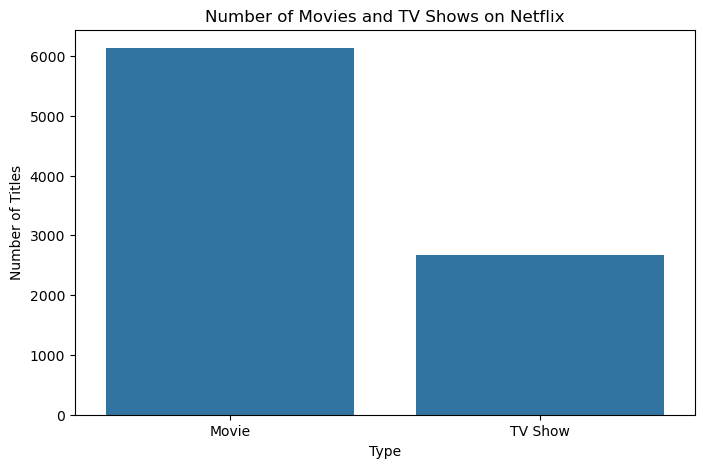

In [23]:
plt.figure(figsize=(8, 5))  # count how many total number of counts belong to each category of type

sns.countplot(data=df, x='type')

plt.title('Number of Movies and TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Number of Titles')
plt.show()

In [24]:
type_percentage = df['type'].value_counts(normalize=True) * 100
type_percentage

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

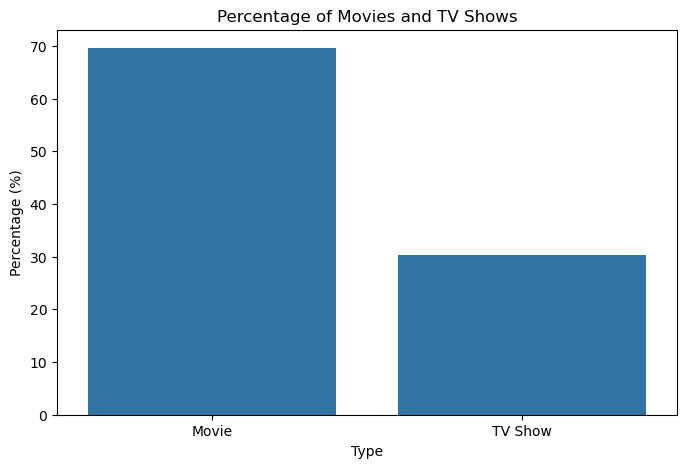

In [25]:
plt.figure(figsize=(8, 5)) # Suing percentage to easily understand comparison

sns.barplot(x=type_percentage.index, y=type_percentage.values)

plt.title('Percentage of Movies and TV Shows')
plt.xlabel('Type')
plt.ylabel('Percentage (%)')
plt.show()

In [26]:
year_counts = df['release_year'].value_counts().sort_index()

year_counts.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: count, dtype: int64

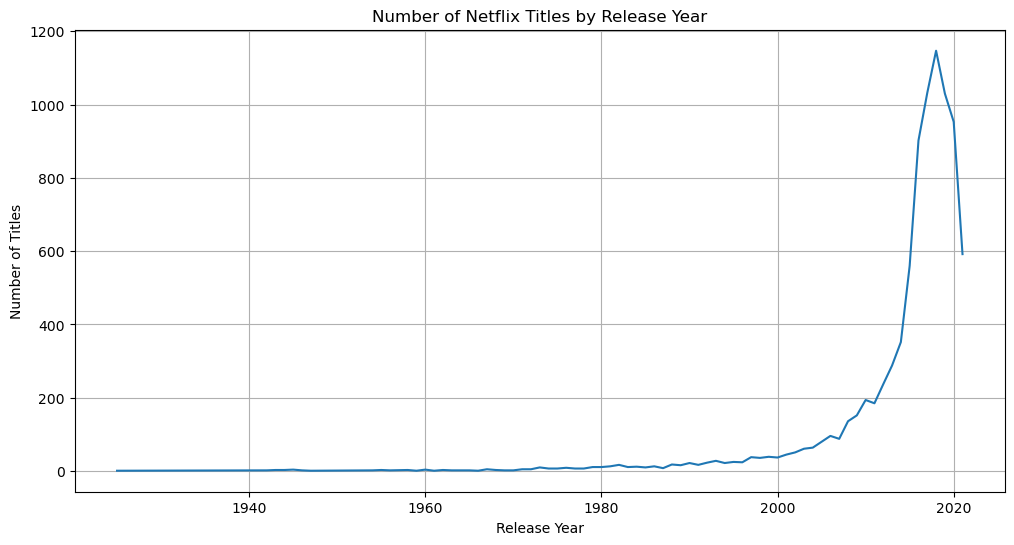

In [29]:
plt.figure(figsize=(12, 6))  # Analyse titles by year

plt.plot(year_counts.index, year_counts.values)

plt.title('Number of Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid()
plt.show()

In [32]:
year_counts.sort_values(ascending=False).head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

In [36]:
year_type_counts = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

year_type_counts.tail(10) # Analysis to understand recent increase is due to moovies, TV show or both

type,Movie,TV Show
release_year,,
2012,173,64
2013,225,63
2014,264,88
2015,398,162
2016,658,244
2017,767,265
2018,767,380
2019,633,397
2020,517,436


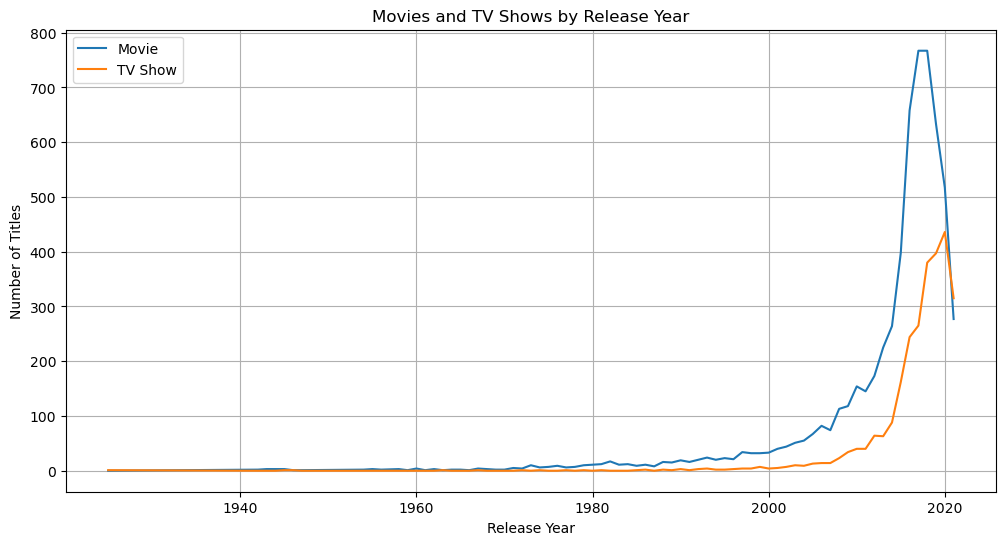

In [37]:
plt.figure(figsize=(12, 6))

plt.plot(year_type_counts.index, year_type_counts['Movie'], label='Movie')
plt.plot(year_type_counts.index, year_type_counts['TV Show'], label='TV Show')

plt.title('Movies and TV Shows by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.grid()
plt.show()

In [38]:
rating_counts = df['rating'].value_counts()

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

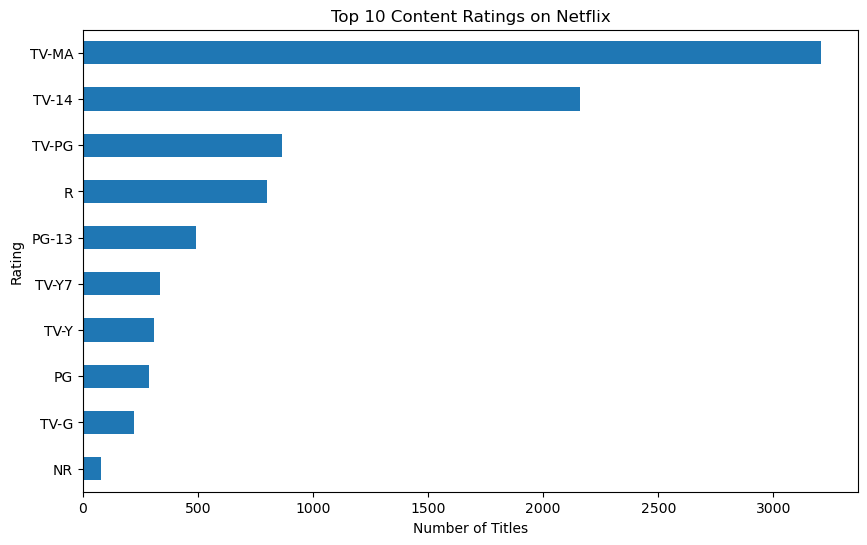

In [40]:
rating_counts = df['rating'].value_counts() # Analysis rating to get to know what type of content is most common in dataset

plt.figure(figsize=(10, 6))
rating_counts.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.show()

## Correlation Analysis

In [49]:
df['duration_minutes'] = df['duration'].str.extract(r'(\d+)').astype(float) # convert info into numerical form before calculating correlation

In [50]:
df['movie_duration'] = df['duration'].where(df['type'] == 'Movie')
df['movie_duration'] = df['movie_duration'].str.extract(r'(\d+)').astype(float)

In [51]:
df[['type', 'duration', 'movie_duration']].head(10)

,type,duration,movie_duration
0,Movie,90 min,90.0
1,TV Show,2 Seasons,NaN
2,TV Show,1 Season,NaN
3,TV Show,1 Season,NaN
4,TV Show,2 Seasons,NaN
5,TV Show,1 Season,NaN
6,Movie,91 min,91.0
7,Movie,125 min,125.0
8,TV Show,9 Seasons,NaN
9,Movie,104 min,104.0


In [52]:
correlation = df[['release_year', 'movie_duration']].corr()

correlation

,release_year,movie_duration
release_year,1.000000,-0.206285
movie_duration,-0.206285,1.000000


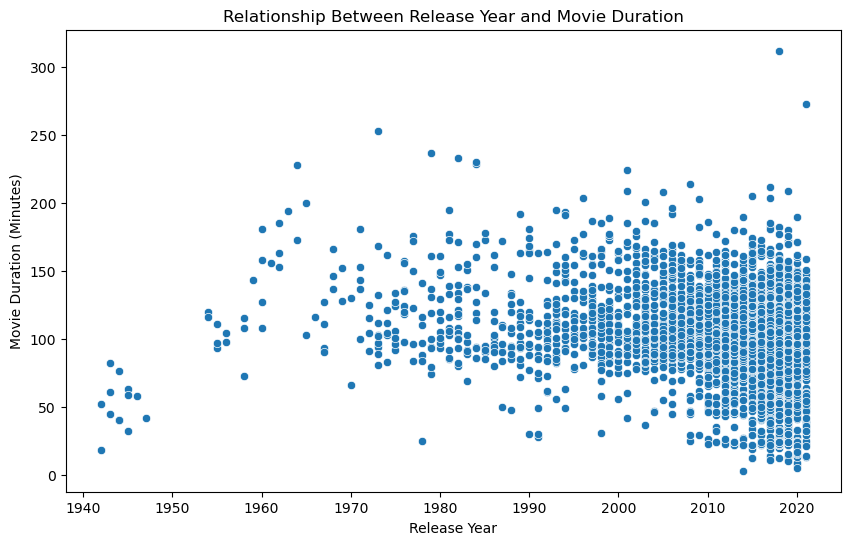

In [53]:
plt.figure(figsize=(10, 6))   #Visualizing correlation
sns.scatterplot(
    data=df,
    x='release_year',
    y='movie_duration'
)

plt.title('Relationship Between Release Year and Movie Duration')
plt.xlabel('Release Year')
plt.ylabel('Movie Duration (Minutes)')
plt.show()

### The correlation between movie release year and movie duration is -0.206, indicating a weak negative relationship. This suggests that movie duration tends to decrease slightly as the release year increases, but the relationship is not strong.